# Workshop 12:Temporal Difference Methods

We looked at Dynamic Programming Planning when a model of the environment is available and Monte Carlo when there is no model available.
Now we look at **Temporal Difference** (TD) learning which is another class of methods that can be used to learn from a model-free environment.

Remember: In Monte Carlo, we had to wait for an episode to finish to be able to calculate the final return $G_t$. This can be slow an inefficient, especially if environments have intermediate rewards.

In TD, we learn after every single step, no matter if we are in a terminal state or not. TD learning updates its values using the observed reward (if any) plus an *estimate* of the future reward. It bootstraps (like Dynamic Programming) from its own learned estimates but learns from experience (like Monte Carlo). 

![Backup Diagrams](./images/backup_diagrams.jpg)

The core idea of TD is to update our value estimate for a state, $V(S_t)$, using the reward we just received, $R_{t+1}$, and our current estimate of the next state's value, $V(S_{t+1})$. The *TD target* is a more informed estimate of the value of $S_t$ than just $V(S_t)$ alone. The difference between our old estimate and the TD target is called the *TD error*:
$$\delta_t=\underbrace{R_{t+1}+\gamma V(S_{t+1})}_{\mathrm{TD~Target}}-V(S_t)$$
We can then update our estimate of $V(S_t)$ using the TD error: $V(S_t)\leftarrow V(S_t)+\alpha\cdot\delta_t$ where $\alpha$ is a learning rate. This fundamental algorithm is called **TD(0)**.

## TD(0) Evaluation
With TD(0) alone, we can do *policy evaluation* of a given, fixed policy. For instance, we can check how good a naive policy is in the FrozenLake environment. Let the fixed policy be the following:
- Always move right (action = 2)


In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Setup the environment and a simple, fixed policy
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")
num_states = env.observation_space.n

# Our fixed policy: always go right (action 2)
policy = np.full(num_states, 2, dtype=int)

# --- Hyperparameters ---
num_episodes = 10000
learning_rate = 0.1
gamma = 0.99

# --- TD(0) Algorithm ---
# Initialize the value function V(s) to all zeros
V = np.zeros(num_states)

print("Running TD(0) to evaluate the 'always go right' policy...")
for episode in range(num_episodes):
    state, info = env.reset()
    done = False
    
    while not done:
        # Get the action from our fixed policy
        action = policy[state]
        
        # Take the action and observe the outcome
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # --- The core TD(0) update ---
        # 1. Calculate the TD Target
        td_target = reward + gamma * V[next_state]
        # 2. Calculate the TD Error
        td_error = td_target - V[state]
        # 3. Update the value function
        V[state] = V[state] + learning_rate * td_error
        
        # Move to the next state
        state = next_state

print("Finished.")

Running TD(0) to evaluate the 'always go right' policy...
Finished.


We can visualize the world and the learned value function side-by-side:

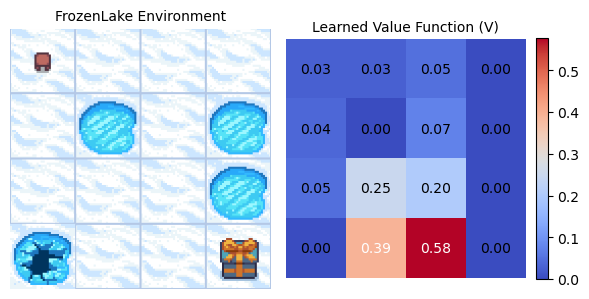

In [10]:
# --- Visualize the Environment and the learned Value Function ---

# Create a figure with two subplots, side by side
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# --- Left Subplot: The Environment ---
axes[0].imshow(env.render())
axes[0].set_title("FrozenLake Environment", fontsize=10)
axes[0].axis('off')

# --- Right Subplot: The Value Function Heatmap ---
grid_size = int(np.sqrt(num_states))
im = axes[1].imshow(V.reshape(grid_size, grid_size), cmap='coolwarm')
axes[1].set_title("Learned Value Function (V)", fontsize=10)
axes[1].axis('off')

# Add text annotations for the values on the heatmap
for i in range(grid_size):
    for j in range(grid_size):
        # Use a contrasting color for the text based on the heatmap value
        text_color = "black" if V[i*grid_size + j] < 0.3 else "white"
        axes[1].text(j, i, f"{V[i*grid_size + j]:.2f}", ha="center", va="center", color=text_color)

# Add a colorbar to the figure that corresponds to the heatmap
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Close the environment now that we're done rendering
env.close()

Great, we can now evaluate any given policy without a model. But how do we find the best policy ("*control*")? To do that, we need to evaluate actions, not just states. This requires learning Q-values:
- The *TD target* is not the full return $G_t$, but $R_{t+1} + \gamma Q(S_{t+1}, A_{t+1})$.
- The *TD error* measures the difference between our estimate and the TD target $\delta_t=R_{t+1}+\gamma Q(S_{t+1},A_{t+1})-Q(S_t,A_t)$

This leads to the general **TD update** rule: $Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\cdot\delta_t$ which nudges our current estimate in the direction of the TD target by a learning rate $\alpha$.

This brings us to our first TD control algorithm: 

## SARSA (TD Control, On-Policy)

SARSA (short for **S**tate-**A**ction-**R**eward-**S**tate-**A**ction, the 5-tuple (S, A, R, S', A') it uses for updates) is an **on-policy** TD algorithm. This means it learns the value of the policy it is currently following (including its exploratory actions).
The update rule uses the Q-value of the next action ($A'$) chosen by the policy:
$$Q(S,A)\leftarrow Q(S,A)+\alpha[R+\gamma Q(S^{\prime},A^{\prime})-Q(S,A)]$$

Because $A'$ is determined by our current $\epsilon$-greedy policy, the agent learns cautiously. It accounts for the fact that it might make a non-optimal (exploratory) move in the next step.

The full algorithm is shown below:

![Pseudocode SARSA](./images/pseudocode_sarsa.jpg)

Training SARSA agent...
Training finished.


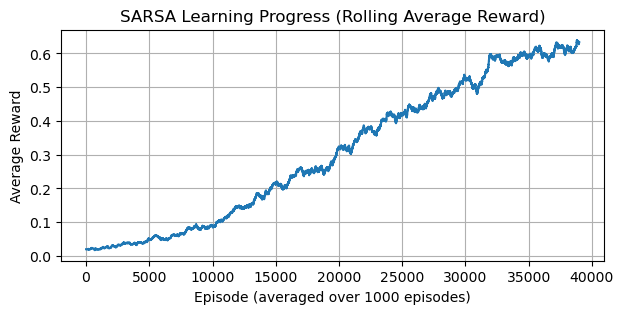

In [3]:
from collections import defaultdict

# --- Setup ---
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")
num_actions = env.action_space.n

# --- Hyperparameters ---
num_episodes = 40_000
learning_rate = 0.1
gamma = 0.99
epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
epsilon_decay = 0.9999

# --- Initialization ---
Q = defaultdict(lambda: np.zeros(num_actions))
episode_rewards_history = []

print("Training SARSA agent...")
# --- Main Training Loop ---
for episode in range(num_episodes):
    state, info = env.reset()
    done = False
    
    # Choose the first action using the epsilon-greedy policy
    if np.random.random() < epsilon:
        action = env.action_space.sample()
    else:
        action = np.argmax(Q[state])
        
    while not done:
        # 1. Take the chosen action
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # 2. Choose the NEXT action (A') using the policy for the NEXT state (S')
        if np.random.random() < epsilon:
            next_action = env.action_space.sample()
        else:
            next_action = np.argmax(Q[next_state])
            
        # 3. Perform the SARSA update
        td_target = reward + gamma * Q[next_state][next_action]
        td_error = td_target - Q[state][action]
        Q[state][action] = Q[state][action] + learning_rate * td_error
        
        # 4. Move to the next state and action for the next iteration
        state = next_state
        action = next_action

    # Log the final reward of the episode
    episode_rewards_history.append(reward)
    
    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training finished.")

# --- Visualize Results ---
# Calculate and plot the rolling average of rewards
window_size = 1000
rolling_avg_rewards = np.convolve(episode_rewards_history, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(7, 3))
plt.plot(rolling_avg_rewards)
plt.title("SARSA Learning Progress (Rolling Average Reward)")
plt.xlabel(f"Episode (averaged over {window_size} episodes)")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

In [30]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# extract policy
policy_sarsa = np.array([np.argmax(Q[s]) if s in Q else 0 for s in range(num_states)])

# animation
frames = []
state, info = env.reset()
done = False
for _ in range(200):
    frames.append(env.render())
    if done: break
    action = policy_sarsa[state]
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
env.close()

fig = plt.figure(figsize=(4, 4))
plt.axis('off')
patch = plt.imshow(frames[0])
def animate(i):
    patch.set_data(frames[i])
    return patch,

anim = FuncAnimation(fig, animate, frames=len(frames), interval=200, blit=True)
plt.close(fig)
HTML(anim.to_html5_video())

This looks relatively good! Let's have a look at the state values, which we can obtain simply from 
$$ V(S) = \max_a Q(S,a) $$
And let's also plot the maximizing action for each state:

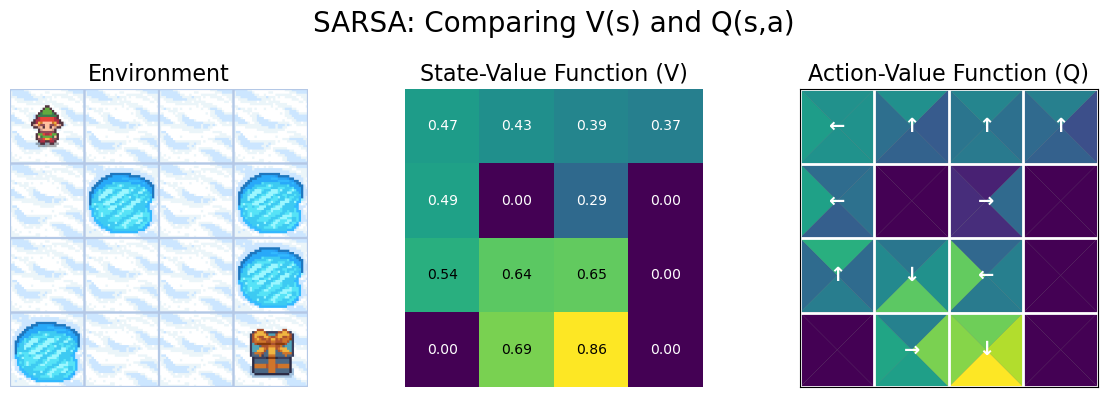

In [4]:
import matplotlib.patches as patches

# --- Extract V(s) from Q(s,a) ---
V_sarsa = np.zeros(num_states)
for state in range(num_states):
    V_sarsa[state] = np.max(Q[state])

# --- Visualize the Environment, V-function, and Q-function ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("SARSA: Comparing V(s) and Q(s,a)", fontsize=20)
grid_size = int(np.sqrt(num_states))

# --- 1. Left Subplot: The Environment ---
env_vis = gym.make("FrozenLake-v1", is_slippery=True, render_mode='rgb_array')
env_vis.reset()
axes[0].imshow(env_vis.render())
axes[0].set_title("Environment", fontsize=16)
axes[0].axis('off')
env_vis.close()

# --- 2. Middle Subplot: The V-Value Heatmap ---
# We use the V_sarsa values for normalization here
norm_v = plt.Normalize(V_sarsa.min(), V_sarsa.max())
axes[1].imshow(V_sarsa.reshape(grid_size, grid_size), cmap='viridis', norm=norm_v)
axes[1].set_title("State-Value Function (V)", fontsize=16)
axes[1].axis('off')

for i in range(grid_size):
    for j in range(grid_size):
        text_color = "black" if norm_v(V_sarsa[i*grid_size + j]) > 0.6 else "white"
        axes[1].text(j, i, f"{V_sarsa[i*grid_size + j]:.2f}", ha="center", va="center", color=text_color)

# --- 3. Right Subplot: The Q-Value Grid ---
axes[2].set_title("Action-Value Function (Q)", fontsize=16)
axes[2].set_aspect('equal')
axes[2].set_xticks(range(grid_size + 1))
axes[2].set_yticks(range(grid_size + 1))
axes[2].grid(True, which='both', color='white', linewidth=2)
axes[2].set_facecolor('gray')
axes[2].tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
axes[2].invert_yaxis()

# Find global min and max Q-values for consistent color mapping
q_min = min(q_val for q_vals in Q.values() for q_val in q_vals)
q_max = max(q_val for q_vals in Q.values() for q_val in q_vals)
norm_q = plt.Normalize(q_min, q_max)
cmap = plt.cm.viridis

action_map_arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}

for state in range(num_states):
    row, col = divmod(state, grid_size)
    q_vals = Q[state]
    
    vertices = {
        0: [[col, row], [col, row + 1], [col + 0.5, row + 0.5]],
        1: [[col, row + 1], [col + 1, row + 1], [col + 0.5, row + 0.5]],
        2: [[col + 1, row], [col + 1, row + 1], [col + 0.5, row + 0.5]],
        3: [[col, row], [col + 1, row], [col + 0.5, row + 0.5]]
    }
    
    for action, q_value in enumerate(q_vals):
        polygon = patches.Polygon(vertices[action], facecolor=cmap(norm_q(q_value)))
        axes[2].add_patch(polygon)
        
    # Only add arrow if the state has been explored ---
    if not np.all(q_vals == 0):
        best_action = np.argmax(q_vals)
        axes[2].text(col + 0.5, row + 0.5, action_map_arrows[best_action],
                     ha='center', va='center', fontsize=14, color='white', weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Q-Learning: TD Control, Off-Policy

So far, we have been doing *on-policy* learning. SARSA learns values by following its own policy, including exploration. It predicts the value of a specific state-action pair given that it follows its current (not optimal) policy.

Q-Learning, on the other hand, learns values by following an *optimal* policy. It predicts the value of a specific state-action pair given that it follows the optimal policy thereafter, making it an **off-policy** learning algorithm.
You can think of it like this: 
- SARSA is a human learning to drive a car through their own decisions only, including exploratory ones like driving down a hill. ("Given that I'm acting like I do, what is the value of breaking right now?")
- Q-Learning is a human learning to drive a car through a simulator where they do random stuff and adjust their target policy for the real world. ("Given that I would follow the learned optimal behavior afterwards, what is the value of breaking right now?")

This means, that off-policy learners learn to exploit even when they are collecting experiences purely through exploration. This makes Q-Learning more "optimistic" than SARSA.

The update rule is a little bit different, as the TD target is different. Instead of using the Q-value of the next action taken ($A'$), we use the Q-value of the best possible action (argmax) in the next state.
$$Q(S,A)\leftarrow Q(S,A)+\alpha[R+\gamma\max_{a^\prime}Q(S^\prime,a^\prime)-Q(S,A)]$$

Let's look at the same example again, this time with Q-Learning:

![Q-Learning: TD Control, Off-Policy](./images/pseudocode_qlearning.jpg)



Training Q-Learning agent...
Training finished.


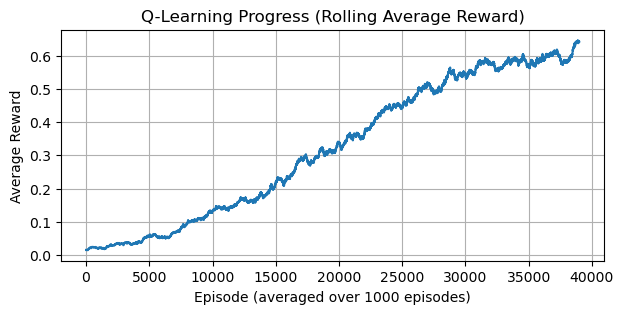

In [45]:
# --- Setup ---
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode='rgb_array')
num_actions = env.action_space.n
num_states = env.observation_space.n

# --- Hyperparameters (same as SARSA for direct comparison) ---
num_episodes = 40_000
learning_rate = 0.1
gamma = 0.99
epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
epsilon_decay = 0.9999

# --- Initialization ---
Q_q_learning = defaultdict(lambda: np.zeros(num_actions))
episode_rewards_history_q = []

print("Training Q-Learning agent...")
# --- Main Training Loop ---
for episode in range(num_episodes):
    state, info = env.reset()
    done = False
    
    while not done:
        # Choose action using epsilon-greedy policy
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q_q_learning[state])
            
        # Take the action
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # --- The core Q-Learning update ---
        # 1. Find the max Q-value for the next state (the greedy choice)
        max_next_q = np.max(Q_q_learning[next_state])
        # 2. Calculate the TD Target
        td_target = reward + gamma * max_next_q
        # 3. Calculate the TD Error and update
        td_error = td_target - Q_q_learning[state][action]
        Q_q_learning[state][action] = Q_q_learning[state][action] + learning_rate * td_error
        
        # Move to the next state
        state = next_state

    # Log the final reward
    episode_rewards_history_q.append(reward)
    
    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training finished.")

# --- Visualize Results ---
window_size = 1000
rolling_avg_rewards_q = np.convolve(episode_rewards_history_q, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(7, 3))
plt.plot(rolling_avg_rewards_q)
plt.title("Q-Learning Progress (Rolling Average Reward)")
plt.xlabel(f"Episode (averaged over {window_size} episodes)")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()

In [46]:
# extract policy
policy_q_learning = np.array([np.argmax(Q_q_learning[s]) if s in Q_q_learning else 0 for s in range(num_states)])

# animation
frames = []
state, info = env.reset()
done = False
for _ in range(200):
    frames.append(env.render())
    if done: break
    action = policy_q_learning[state]
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
env.close()

fig = plt.figure(figsize=(4, 4))
plt.axis('off')
patch_q_learning = plt.imshow(frames[0])
def animate(i):
    patch_q_learning.set_data(frames[i])
    return patch_q_learning,

anim = FuncAnimation(fig, animate, frames=len(frames), interval=200, blit=True)
plt.close(fig)
HTML(anim.to_html5_video())

Let's compare the state and state-action values!

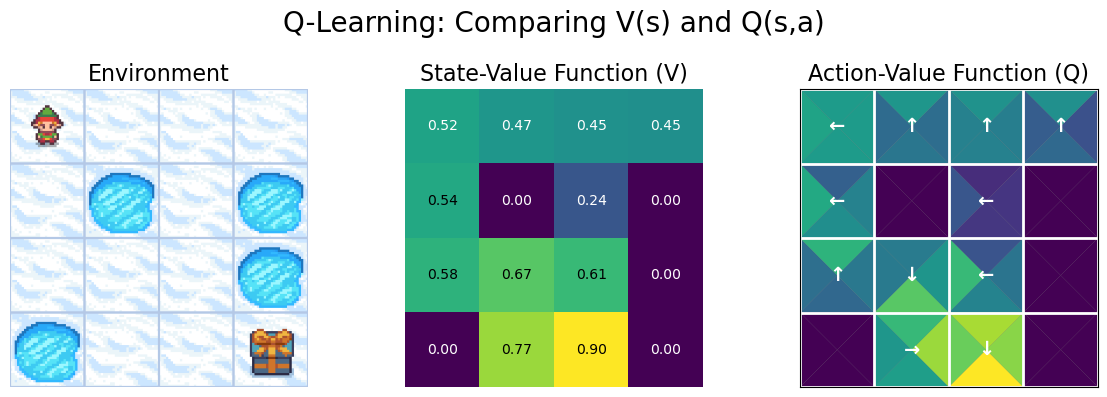

In [47]:
import matplotlib.patches as patches

# --- Extract V(s) from the Q-Learning Q-table ---
V_q_learning = np.zeros(num_states)
for state in range(num_states):
    V_q_learning[state] = np.max(Q_q_learning[state])

# --- Visualize the Environment, V-function, and Q-function ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle("Q-Learning: Comparing V(s) and Q(s,a)", fontsize=20)
grid_size = int(np.sqrt(num_states))

# --- 1. Left Subplot: The Environment ---
env_vis = gym.make("FrozenLake-v1", is_slippery=True, render_mode='rgb_array')
env_vis.reset()
axes[0].imshow(env_vis.render())
axes[0].set_title("Environment", fontsize=16)
axes[0].axis('off')
env_vis.close()

# --- 2. Middle Subplot: The V-Value Heatmap ---
norm_v = plt.Normalize(V_q_learning.min(), V_q_learning.max())
axes[1].imshow(V_q_learning.reshape(grid_size, grid_size), cmap='viridis', norm=norm_v)
axes[1].set_title("State-Value Function (V)", fontsize=16)
axes[1].axis('off')

for i in range(grid_size):
    for j in range(grid_size):
        text_color = "black" if norm_v(V_q_learning[i*grid_size + j]) > 0.6 else "white"
        axes[1].text(j, i, f"{V_q_learning[i*grid_size + j]:.2f}", ha="center", va="center", color=text_color)

# --- 3. Right Subplot: The Q-Value Grid ---
axes[2].set_title("Action-Value Function (Q)", fontsize=16)
axes[2].set_aspect('equal')
axes[2].set_facecolor('gray')
axes[2].tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)
axes[2].invert_yaxis()

q_min = min(q_val for q_vals in Q_q_learning.values() for q_val in q_vals) if Q_q_learning else 0
q_max = max(q_val for q_vals in Q_q_learning.values() for q_val in q_vals) if Q_q_learning else 0
norm_q = plt.Normalize(q_min, q_max if q_max > q_min else q_min + 1)
cmap = plt.cm.viridis

action_map_arrows = {0: "←", 1: "↓", 2: "→", 3: "↑"}

for state in range(num_states):
    row, col = divmod(state, grid_size)
    q_vals = Q_q_learning[state]
    
    vertices = {
        0: [[col, row], [col, row + 1], [col + 0.5, row + 0.5]],
        1: [[col, row + 1], [col + 1, row + 1], [col + 0.5, row + 0.5]],
        2: [[col + 1, row], [col + 1, row + 1], [col + 0.5, row + 0.5]],
        3: [[col, row], [col + 1, row], [col + 0.5, row + 0.5]]
    }
    
    for action, q_value in enumerate(q_vals):
        polygon = patches.Polygon(vertices[action], facecolor=cmap(norm_q(q_value)))
        axes[2].add_patch(polygon)
        
    if not np.all(q_vals == 0):
        best_action = np.argmax(q_vals)
        axes[2].text(col + 0.5, row + 0.5, action_map_arrows[best_action],
                     ha='center', va='center', fontsize=14, color='white', weight='bold')

axes[2].set_xticks(range(grid_size + 1))
axes[2].set_yticks(range(grid_size + 1))
axes[2].grid(True, which='both', color='white', linewidth=2)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## On-Policy vs. Off-Policy Control: Cliff-Walk
In the `FrozenLake` environment the difference between the two algorithms was negligible. Let's try the `CliffWalking` environment instead, which is famous for producing different behavior between on-policy and off-policy methods.

In this environment the agent needs to learn to avoid the cliff and reach the goal. The agent can move up, down, left, and right. The agent starts in the bottom left corner of the grid and the goal is in the bottom right corner.
The environemnt is described here in detail: https://gymnasium.farama.org/environments/toy_text/cliff_walking/

![CliffWalk](./images/cliff_walking.gif)

This environment gives a small negative reward for each step and a large negative reward if the agent falls into the cliff. This created a conflict: The shortest, most optimal path is right along the cliff edge.
The hypothesis is the following:
- **SARSA** will learn a safer, but longer path because its own actions (exploration) might lead it off the cliff along the optimal path.
- **Q-Learning** will find the true optimal path because it doesn't care about falling during exploration.




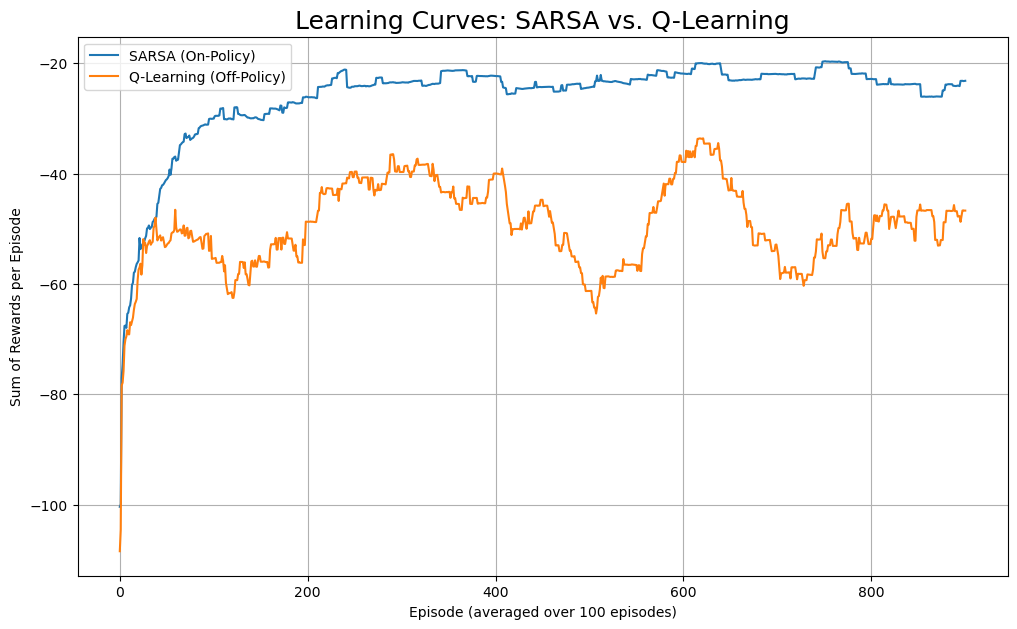

In [5]:
# --- Setup ---
env = gym.make("CliffWalking-v0", render_mode='rgb_array')
num_actions = env.action_space.n
# The state space is a 4x12 grid
num_states = env.observation_space.n
env_shape = env.unwrapped.shape

# --- Hyperparameters ---
num_episodes = 1000
learning_rate = 0.2
gamma = 0.99
epsilon = 0.1 # A constant epsilon works well here

# --- Training Code with Reward Tracking ---
sarsa_rewards = []
q_learning_rewards = []

# --- Train SARSA ---
Q_sarsa = defaultdict(lambda: np.zeros(num_actions))
for _ in range(num_episodes):
    state, info = env.reset()
    done = False
    total_reward_sarsa = 0
    action = np.argmax(Q_sarsa[state]) if np.random.random() > epsilon else env.action_space.sample()
    while not done:
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward_sarsa += reward
        next_action = np.argmax(Q_sarsa[next_state]) if np.random.random() > epsilon else env.action_space.sample()
        Q_sarsa[state][action] += learning_rate * (reward + gamma * Q_sarsa[next_state][next_action] - Q_sarsa[state][action])
        state, action = next_state, next_action
    sarsa_rewards.append(total_reward_sarsa)

# --- Train Q-Learning ---
Q_q_learning = defaultdict(lambda: np.zeros(num_actions))
for _ in range(num_episodes):
    state, info = env.reset()
    done = False
    total_reward_q = 0
    while not done:
        action = np.argmax(Q_q_learning[state]) if np.random.random() > epsilon else env.action_space.sample()
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward_q += reward
        Q_q_learning[state][action] += learning_rate * (reward + gamma * np.max(Q_q_learning[next_state]) - Q_q_learning[state][action])
        state = next_state
    q_learning_rewards.append(total_reward_q)

# --- Plotting the Learning Curves ---
window_size = 100
sarsa_rolling_avg = np.convolve(sarsa_rewards, np.ones(window_size)/window_size, mode='valid')
q_learning_rolling_avg = np.convolve(q_learning_rewards, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(12, 7))
plt.plot(sarsa_rolling_avg, label='SARSA (On-Policy)')
plt.plot(q_learning_rolling_avg, label='Q-Learning (Off-Policy)')
plt.title('Learning Curves: SARSA vs. Q-Learning', fontsize=18)
plt.xlabel(f'Episode (averaged over {window_size} episodes)')
plt.ylabel('Sum of Rewards per Episode')
plt.legend()
plt.grid(True)
plt.show()

Let's look at the final state values for the two agents and compare them with regard to our hypothesis!

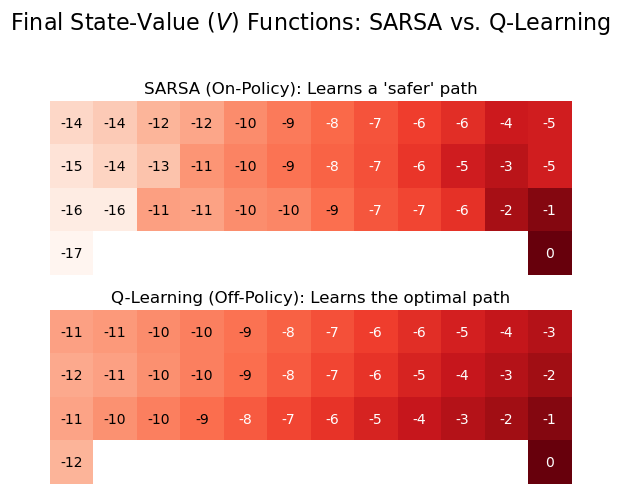

In [14]:
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt

# This assumes Q_sarsa, Q_q_learning, num_states, and env_shape are already defined
# from the previous training cell.

# --- Extract V-functions for both agents ---
V_sarsa = {s: np.max(q) for s, q in Q_sarsa.items()}
V_sarsa_grid = np.array([V_sarsa.get(s, 0) for s in range(num_states)]).reshape(env_shape)

V_q_learning = {s: np.max(q) for s, q in Q_q_learning.items()}
V_q_grid = np.array([V_q_learning.get(s, 0) for s in range(num_states)]).reshape(env_shape)

# --- Create a mask for the cliff states ---
# The cliff is in the last row (row 3), from column 1 to 10.
cliff_mask = np.zeros(env_shape, dtype=bool)
cliff_mask[3, 1:11] = True

# Apply the mask to our V-value grids
V_sarsa_masked = ma.masked_array(V_sarsa_grid, mask=cliff_mask)
V_q_learning_masked = ma.masked_array(V_q_grid, mask=cliff_mask)

# --- Create the stacked subplot visualization ---
fig, axes = plt.subplots(2, 1, figsize=(8, 5)) # Adjusted figsize for better text fit
fig.suptitle("Final State-Value ($V$) Functions: SARSA vs. Q-Learning", fontsize=16)

# To ensure a fair color comparison, find the global min/max across both V-functions
vmin = min(V_sarsa_masked.min(), V_q_learning_masked.min())
vmax = max(V_sarsa_masked.max(), V_q_learning_masked.max())
norm = plt.Normalize(vmin, vmax)

# --- Top Subplot: SARSA ---
axes[0].imshow(V_sarsa_masked, cmap='Reds', vmin=vmin, vmax=vmax)
axes[0].set_title("SARSA (On-Policy): Learns a 'safer' path", fontsize=12)
axes[0].axis('off')

# Add text annotations for SARSA V-values
for state in range(num_states):
    row, col = np.unravel_index(state, env_shape)
    if not cliff_mask[row, col]: # Only plot text if it's not a cliff cell
        value = V_sarsa_grid[row, col]
        text_color = "white" if norm(value) > 0.5 else "black"
        axes[0].text(col, row, f"{value:.0f}", ha="center", va="center", color=text_color)

# --- Bottom Subplot: Q-Learning ---
axes[1].imshow(V_q_learning_masked, cmap='Reds', vmin=vmin, vmax=vmax)
axes[1].set_title("Q-Learning (Off-Policy): Learns the optimal path", fontsize=12)
axes[1].axis('off')

# Add text annotations for Q-Learning V-values
for state in range(num_states):
    row, col = np.unravel_index(state, env_shape)
    if not cliff_mask[row, col]: # Only plot text if it's not a cliff cell
        value = V_q_grid[row, col]
        text_color = "white" if norm(value) > 0.5 else "black"
        axes[1].text(col, row, f"{value:.0f}", ha="center", va="center", color=text_color)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()